<a href="https://colab.research.google.com/github/SahilRaut80/Assignments/blob/main/Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('/content/diabetes.csv')

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: >

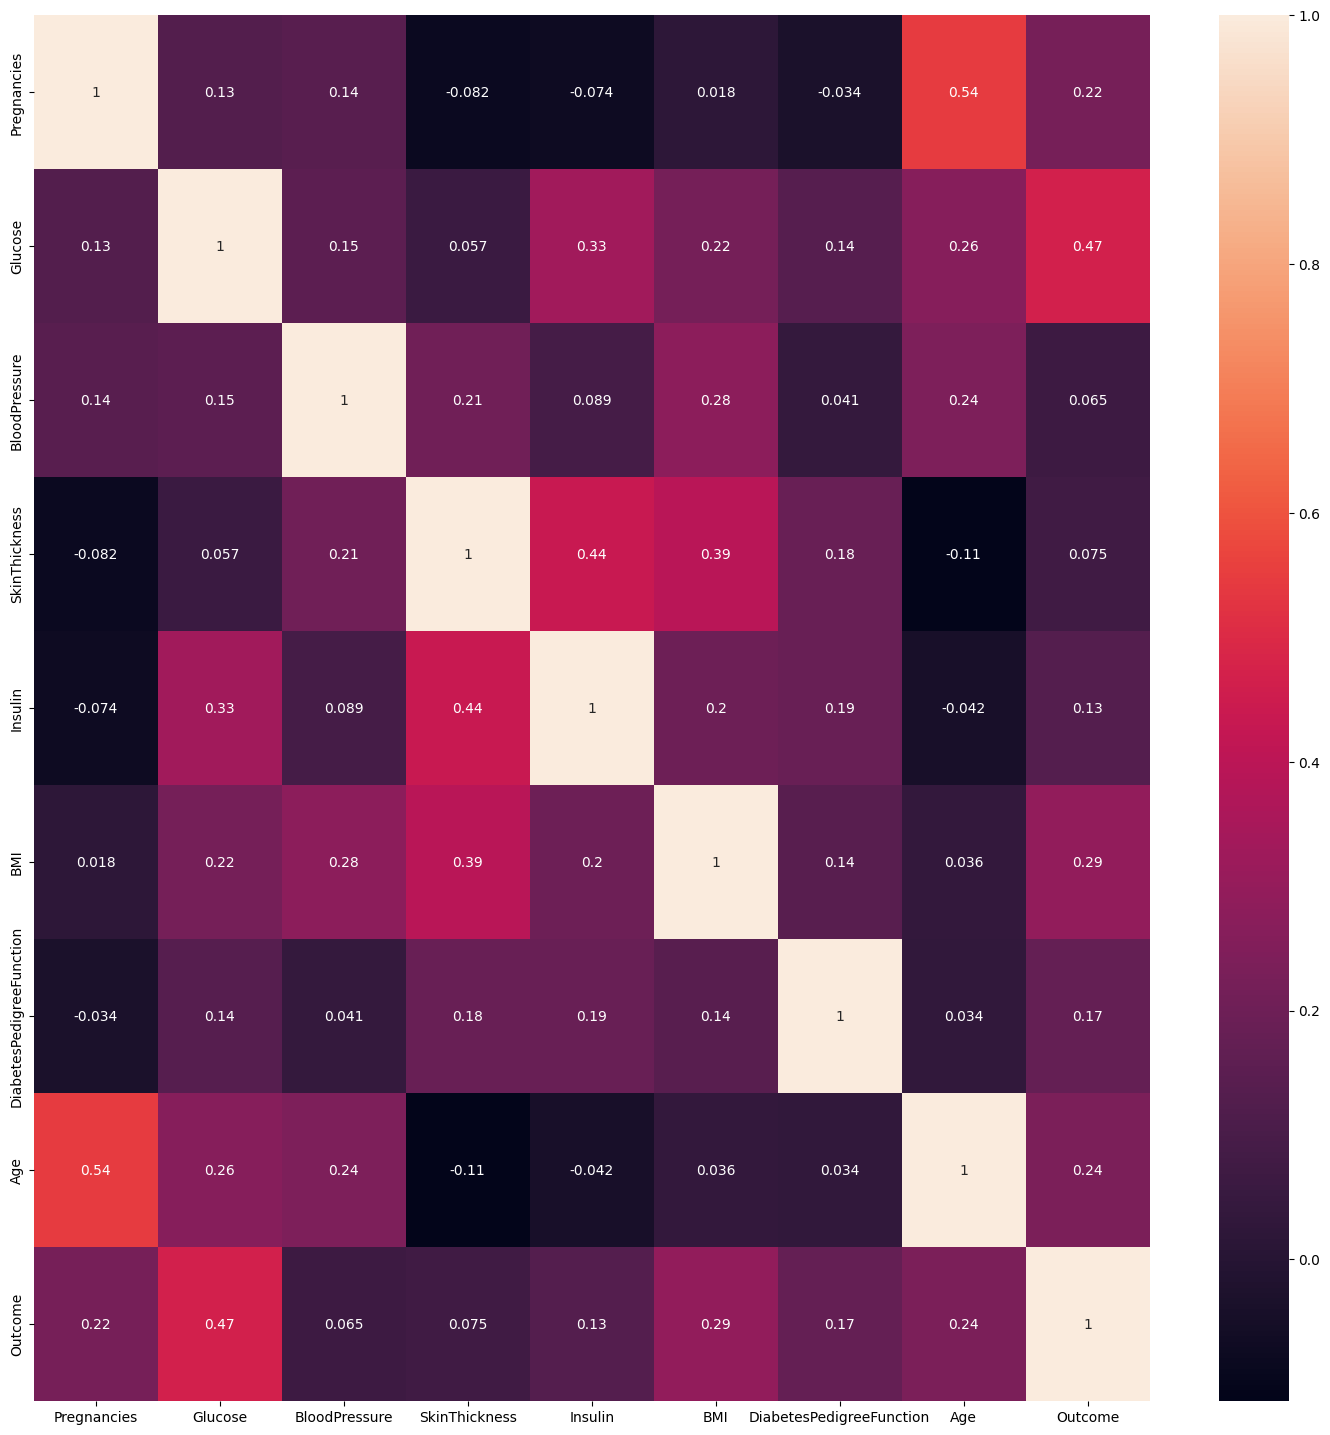

In [ ]:
plt.figure(figsize=(18,18))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:

    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    df[i]=df[i].clip(lower,upper)

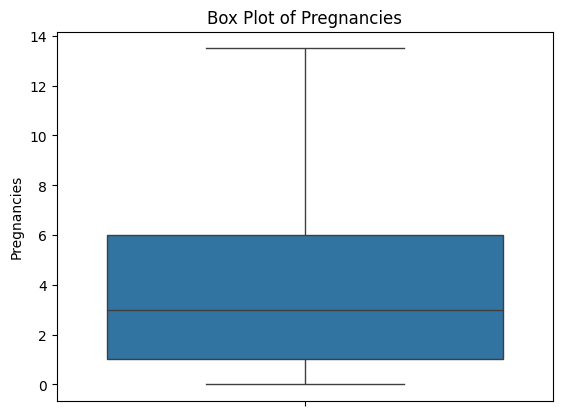

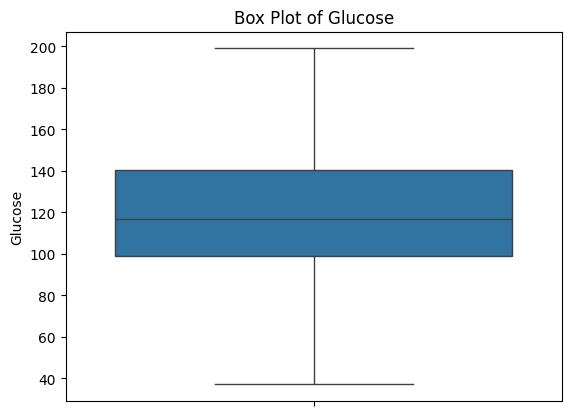

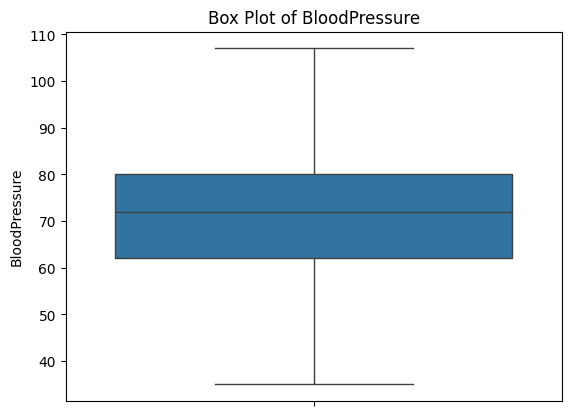

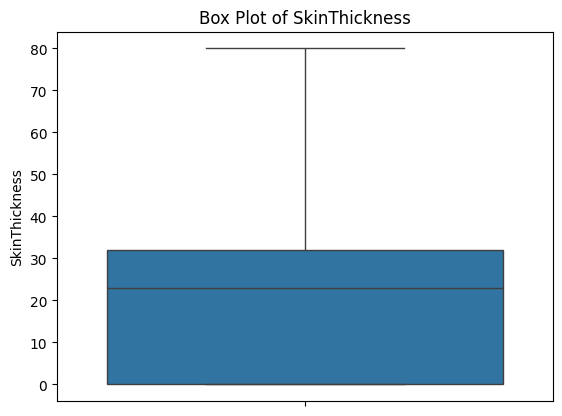

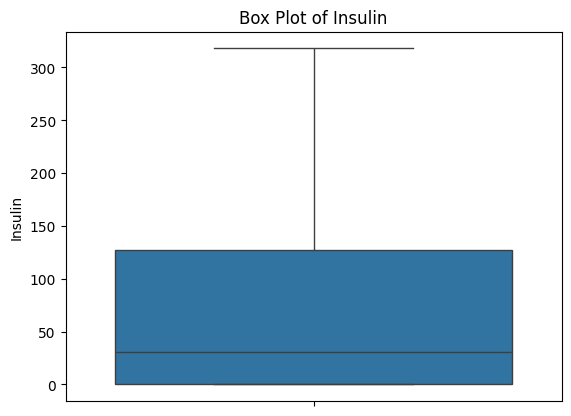

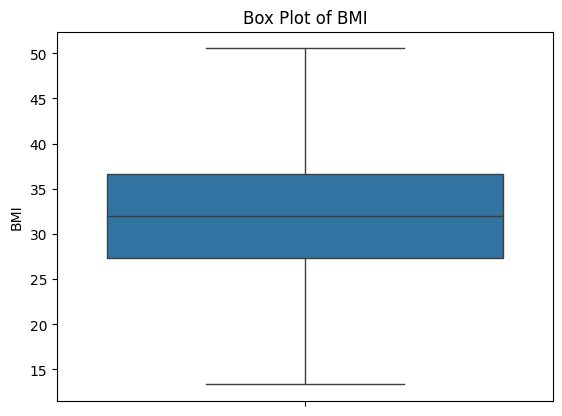

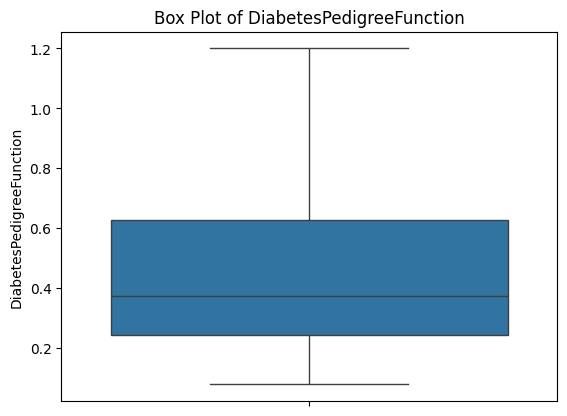

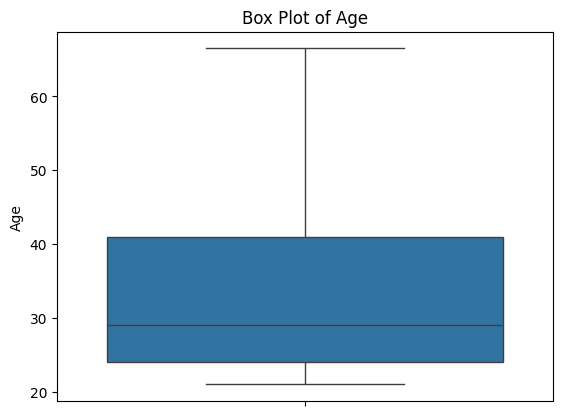

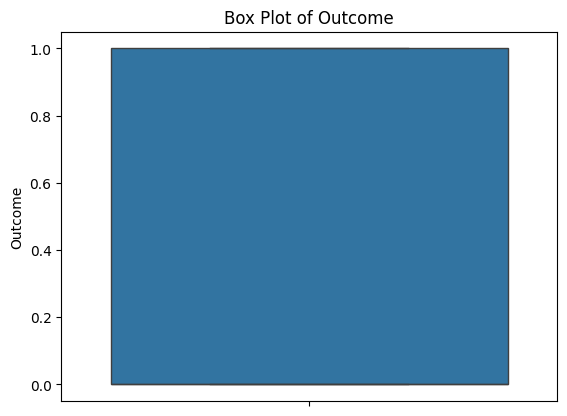

In [ ]:
for col in df.select_dtypes(include=['int','float']).columns:

    sns.boxplot(df[col])

    plt.title(f'Box Plot of {col}')

    plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler,OrdinalEncoder
scaler = MinMaxScaler()
df['DiabetesPedigreeFunction'] = scaler.fit_transform(df[['DiabetesPedigreeFunction']])
df['Glucose'] = scaler.fit_transform(df[['Glucose']])
df['BloodPressure'] = scaler.fit_transform(df[['BloodPressure']])
df['SkinThickness'] = scaler.fit_transform(df[['SkinThickness']])
df['BMI'] = scaler.fit_transform(df[['BMI']])
df['Insulin'] = scaler.fit_transform(df[['Insulin']])

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,0.684942,0.513889,0.4375,0.000000,0.544355,0.489305,50.0,1
1,1.0,0.295753,0.430556,0.3625,0.000000,0.356183,0.243316,31.0,0
2,8.0,0.901158,0.402778,0.0000,0.000000,0.267473,0.529412,32.0,1
3,1.0,0.320463,0.430556,0.2875,0.295481,0.396505,0.079323,21.0,0
4,0.0,0.616988,0.069444,0.4375,0.528094,0.799731,1.000000,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10.0,0.394595,0.569444,0.6000,0.565815,0.525538,0.082888,63.0,0
764,2.0,0.524324,0.486111,0.3375,0.000000,0.630376,0.233512,27.0,0
765,5.0,0.518147,0.513889,0.2875,0.352063,0.345430,0.148841,30.0,0
766,1.0,0.549035,0.347222,0.0000,0.000000,0.450269,0.241533,47.0,1


In [ ]:
x = df.drop(columns =['Outcome'] )
y = df['Outcome']

In [ ]:
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,0.684942,0.513889,0.4375,0.000000,0.544355,0.489305,50.0
1,1.0,0.295753,0.430556,0.3625,0.000000,0.356183,0.243316,31.0
2,8.0,0.901158,0.402778,0.0000,0.000000,0.267473,0.529412,32.0
3,1.0,0.320463,0.430556,0.2875,0.295481,0.396505,0.079323,21.0
4,0.0,0.616988,0.069444,0.4375,0.528094,0.799731,1.000000,33.0
...,...,...,...,...,...,...,...,...
763,10.0,0.394595,0.569444,0.6000,0.565815,0.525538,0.082888,63.0
764,2.0,0.524324,0.486111,0.3375,0.000000,0.630376,0.233512,27.0
765,5.0,0.518147,0.513889,0.2875,0.352063,0.345430,0.148841,30.0
766,1.0,0.549035,0.347222,0.0000,0.000000,0.450269,0.241533,47.0


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=50)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
pred = lr.predict(x_test)

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print('accuracy_score',accuracy_score(y_test,pred))
print('confusion_matrix',confusion_matrix(y_test,pred))
print('classification_report',classification_report(y_test,pred))


accuracy_score 0.7207792207792207
confusion_matrix [[89 12]
 [31 22]]
classification_report               precision    recall  f1-score   support

           0       0.74      0.88      0.81       101
           1       0.65      0.42      0.51        53

    accuracy                           0.72       154
   macro avg       0.69      0.65      0.66       154
weighted avg       0.71      0.72      0.70       154



In [ ]:
lr.predict_proba(x_test)[:,1]

array([0.25963081, 0.9268882 , 0.19302498, 0.103586  , 0.13278184,
       0.24290715, 0.05302645, 0.27375021, 0.4099434 , 0.35081565,
       0.07545205, 0.04713667, 0.06376683, 0.1699292 , 0.2707084 ,
       0.1755329 , 0.67260945, 0.40550599, 0.3378886 , 0.22114717,
       0.91405414, 0.06315803, 0.36757231, 0.19189049, 0.12432797,
       0.26156129, 0.62856044, 0.206845  , 0.50808437, 0.8860651 ,
       0.16246593, 0.17315265, 0.03172563, 0.22226807, 0.33539632,
       0.12719803, 0.10926469, 0.25510384, 0.72034101, 0.11246679,
       0.39453913, 0.37500425, 0.11723387, 0.16574408, 0.09159094,
       0.09469918, 0.63826974, 0.11783181, 0.46407788, 0.18701172,
       0.24676995, 0.16829134, 0.288313  , 0.47602757, 0.15184028,
       0.38069918, 0.25922251, 0.51996012, 0.16394778, 0.07365823,
       0.48148705, 0.07651127, 0.24513491, 0.3115394 , 0.43356764,
       0.66032241, 0.29038105, 0.43446979, 0.59774626, 0.25024857,
       0.06593332, 0.47732161, 0.56159284, 0.03096893, 0.50048

In [ ]:
sigmoid = lr.predict_proba(x_test)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
auc_score=roc_auc_score(y_test,sigmoid)
auc_score


np.float64(0.7836727068933309)

In [ ]:
roc_curve(y_test,sigmoid)


(array([0.        , 0.        , 0.00990099, 0.00990099, 0.01980198,
        0.01980198, 0.02970297, 0.02970297, 0.03960396, 0.03960396,
        0.04950495, 0.04950495, 0.06930693, 0.06930693, 0.08910891,
        0.08910891, 0.11881188, 0.11881188, 0.14851485, 0.14851485,
        0.18811881, 0.18811881, 0.23762376, 0.23762376, 0.24752475,
        0.24752475, 0.26732673, 0.26732673, 0.2970297 , 0.2970297 ,
        0.33663366, 0.33663366, 0.36633663, 0.36633663, 0.40594059,
        0.40594059, 0.44554455, 0.44554455, 0.47524752, 0.47524752,
        0.4950495 , 0.4950495 , 0.61386139, 0.61386139, 0.62376238,
        0.62376238, 1.        ]),
 array([0.        , 0.01886792, 0.01886792, 0.13207547, 0.13207547,
        0.26415094, 0.26415094, 0.30188679, 0.30188679, 0.32075472,
        0.32075472, 0.33962264, 0.33962264, 0.37735849, 0.37735849,
        0.41509434, 0.41509434, 0.49056604, 0.49056604, 0.52830189,
        0.52830189, 0.56603774, 0.56603774, 0.62264151, 0.62264151,
        0.6603

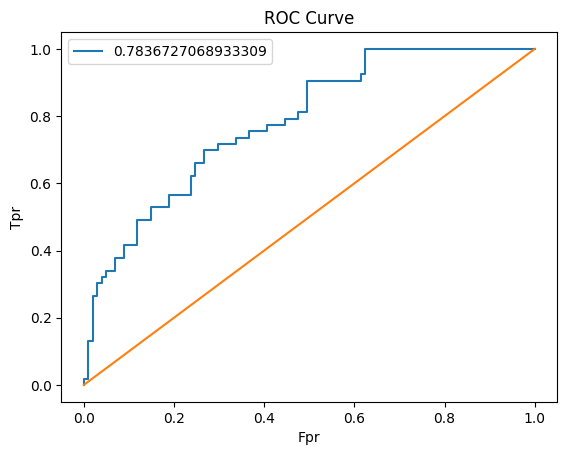

In [ ]:
fpr,tpr,thr=roc_curve(y_test,sigmoid)
plt.plot(fpr,tpr,label=f'{auc_score}')
plt.plot([0,1])
plt.xlabel('Fpr')
plt.ylabel('Tpr')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
import pickle

# Save the model to a file
with open('logistic_model.pkl', 'wb') as file:
    pickle.dump(lr, file)
